<a href="https://colab.research.google.com/github/divyasaminathan02/Sridivyadharshini-Codeboosters-Internship-2026/blob/main/Phase_01_Data_Engineering/Day_02_Database_SQL_Visualisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [114]:
import sqlite3
#python built-in database library
#allows python to store ,create ,connect to  and query sqlite databases
#no pip install needed-sqlite comes with python library

import pandas as pd
#to load data into database(to sql) and to read query results from the databases

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')
#Suppresses non-critical warning messages that cluster output
print("All Libraries imported successfully")
print(f"pandas version:{pd.__version__}")
print(f"sqlite3 version:{sqlite3.version}")

All Libraries imported successfully
pandas version:2.2.2
sqlite3 version:2.6.0


In [115]:
#to mount drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [116]:
df=pd.read_csv('student_performance.csv')
print(f"Dataset Loaded:{df.shape[0]} students,{df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

Dataset Loaded:30 students,13 columns
Columns: ['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [117]:
conn=sqlite3.connect('college.db')
# conn - our connection to the database
# college.db -the file will be created in the colab's filesystem
#if college.db already exists,it just opens it
#if doesnot exist, itcreates it automatically

cursor=conn.cursor()
#create a cursor
#cursor writes sql commands in the database
#every sql query goes through the cursor

#Write the dataframe to the database as a table
df.to_sql(
    'students',  # name of the table to create in the database
    conn,        # which database connection to use
    if_exists='replace', #If 'students' table exists ,replace it
    index=False   #Do not write dataframe row numbers as column
)
#to_sql() automatically:
# 1.Creates the table with correct column names and types
# 2.Inserts all 30 rows from the DataFrame
#Without to_sql(),we would need to write 30 INSERT statements

#verify the table was created
cursor.execute("SELECT COUNT(*) FROM students")
#cursor.execute() runs a sql command
#SELECT Count(*) counts all rows in the students table

count=cursor.fetchone()[0]
#.fetchone() retrives the first result row


print(f"Database 'college.db' created successfully")
print(f"Table 'students' has {count} rows")

Database 'college.db' created successfully
Table 'students' has 30 rows


In [118]:
#inspect the table structure
#PRAGMA is a special SQL command
#table_info() shows the structure of the table

cursor.execute("PRAGMA table_info(students)")
columns_info =cursor.fetchall()
#fetchall() retrives ALL result rows(not just one)

print("Table structure of 'students'")
print(f"{'Column Name': <25} {'Data Type' : <12}")
#:<25 means left-align in 25 characters (for neat formatting)
print("-"*38)

for col in columns_info:
  #col is a tuple :(id,name,type,notnull,default,pk)
  print(f"{col[1]:<25}{col[2]:<12}")
  #col[1]=column name,col[2]=datatype


Table structure of 'students'
Column Name               Data Type   
--------------------------------------
student_id               INTEGER     
name                     TEXT        
age                      INTEGER     
gender                   TEXT        
department               TEXT        
semester                 INTEGER     
math_score               INTEGER     
science_score            INTEGER     
english_score            INTEGER     
programming_score        INTEGER     
attendance_percentage    INTEGER     
city                     TEXT        
admission_year           INTEGER     


THE STANDARD SQL QUERY PATTERN

~~~sql
SELECT column1,column2       --which columns to show

FROM table_name              --which table to read from

WHERE condition              --Filter rows

GROUP BY column              --Group rows

HAVING group_condition       --Filter groups

ORDER BY column DESC         --Sort results

LIMIT 10;                    --Max rows to return

In [119]:
def run_query(sql, description=""):
  """

  Runs a SQL query and returns results as a Pandas DataFrame

  Parameters:
  ----------
  sql       : str - The SQL query string to execute
  description: str - A label to print the above results

  Returns:

  -------
  Pandas DataFrame containing the results of the query

  """
  if description:
    print(f"\n{'='*55}")
    print(f"  {description}")
    print(f"{'='*55}")

  result = pd.read_sql_query(sql, conn)

  print(result.to_string(index=False))
  return result

print("Helper  Function 'run_query' defined succesfully!")
print("Usage: run_query(sql_string, description_label)")

Helper  Function 'run_query' defined succesfully!
Usage: run_query(sql_string, description_label)


# SQLITE STUDENT DATABASE

1.Find total number of students

2.Display all column names and data types using PRAGMA

3.Show first five rows from the students table

4.Display students with math marks greater than 80

5.Count the number of male and female students

6.Find average Math score of all students


In [120]:
query1 = """
   SELECT student_id, name , department, math_score, attendance_percentage
   FROM students
   LIMIT 10
"""
result1 = run_query(query1, "Query 1 : First 10 students in the database (SELECT + LIMIT)")



  Query 1 : First 10 students in the database (SELECT + LIMIT)
 student_id         name       department  math_score  attendance_percentage
       1001 Aarav Sharma Computer Science          85                     92
       1002  Priya Patel Computer Science          76                     87
       1003  Rohit Verma      Electronics          65                     78
       1004  Sneha Reddy       Mechanical          70                     95
       1005   Arjun Nair Computer Science          92                     90
       1006  Meera Joshi      Electronics          58                     72
       1007  Kiran Kumar            Civil          73                     85
       1008  Divya Singh Computer Science          88                     96
       1009 Rahul Mishra       Mechanical          62                     68
       1010   Ananya Das Computer Science          95                     98


In [121]:
query2="""
SELECT name,department,math_score
FROM students
ORDER BY math_score DESC
LIMIT 5
"""
result2=run_query(query2,"Query 2 : TOP 5 math scores (ORDER BY DESC + LIMIT)")


  Query 2 : TOP 5 math scores (ORDER BY DESC + LIMIT)
          name       department  math_score
    Ananya Das Computer Science          95
   Tanvi Mehta Computer Science          93
    Arjun Nair Computer Science          92
Akanksha Yadav Computer Science          91
Swati Kulkarni Computer Science          90


In [122]:
query3="""
SELECT name ,math_score,science_score,programming_score,attendance_percentage
FROM students
WHERE department='Computer Science'
ORDER BY programming_score DESC
"""
result3=run_query(query3,"Query 3 : Computer Science Students (WHERE Filter)")
print(f"Total CS students found: {len(result3)}")


  Query 3 : Computer Science Students (WHERE Filter)
          name  math_score  science_score  programming_score  attendance_percentage
    Ananya Das          95             89                 97                     98
   Tanvi Mehta          93             90                 96                     97
    Arjun Nair          92             88                 95                     90
Akanksha Yadav          91             93                 94                     95
   Divya Singh          88             91                 93                     96
Swati Kulkarni          90             87                 92                     94
  Aarav Sharma          85             78                 91                     92
     Amit Bose          86             82                 89                     91
    Suresh Rao          83             86                 88                     88
 Gaurav Shukla          84             79                 87                     87
  Nisha Kapoor        

In [123]:
query4="""
  select name, department, attendance_percentage
  from students
  where attendance_percentage>90
  and department!='civil'
  order by attendance_percentage desc
"""
result4=run_query(query4, "Query 4: Students with >90% attendance excluding civil department")


  Query 4: Students with >90% attendance excluding civil department
          name       department  attendance_percentage
    Ananya Das Computer Science                     98
   Tanvi Mehta Computer Science                     97
   Divya Singh Computer Science                     96
   Sneha Reddy       Mechanical                     95
Akanksha Yadav Computer Science                     95
Swati Kulkarni Computer Science                     94
  Ritu Agarwal      Electronics                     93
  Aarav Sharma Computer Science                     92
 Kavya Nambiar       Mechanical                     91
     Amit Bose Computer Science                     91


In [124]:
query5="""
SELECT
department,
COUNT(*)           AS num_students,
ROUND(AVG(math_score),2)    AS avg_math,
ROUND(AVG(science_score),2) AS avg_science,
ROUND(AVG(programming_score),2) AS avg_programming,
ROUND(AVG(attendance_percentage),2) AS avg_attendance
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""
result5=run_query(query5,"Query 5: Department Averages")


  Query 5: Department Averages
      department  num_students  avg_math  avg_science  avg_programming  avg_attendance
Computer Science            13     85.62        84.46            89.23           90.69
      Mechanical             6     71.00        76.50            49.33           83.50
     Electronics             6     71.00        74.17            61.50           80.33
           Civil             5     63.40        66.60            40.60           74.60


In [125]:
query6="""
SELECT
department,
ROUND(AVG(math_score),2) AS avg_math,
COUNT(*) AS students
FROM students
GROUP BY department
HAVING AVG(math_score)>70
ORDER BY avg_math DESC
"""
result6=run_query(query6,"Query 6: Departments with average maths score >70")


  Query 6: Departments with average maths score >70
      department  avg_math  students
Computer Science     85.62        13
      Mechanical     71.00         6
     Electronics     71.00         6


In [126]:
query7="""
SELECT
gender,
COUNT(*) AS num_students,
ROUND(AVG(math_score),2) AS avg_math,
ROUND(AVG(programming_score),2) AS avg_programming,
ROUND(AVG(attendance_percentage),2) AS avg_attendance
FROM students
GROUP BY gender
"""
result7=run_query(query7,"Query 7: Gender-wise performance Analysis")


  Query 7: Gender-wise performance Analysis
gender  num_students  avg_math  avg_programming  avg_attendance
Female            15     78.47             70.2           88.53
  Male            15     73.67             65.0           80.47


In [127]:
query8 ="""
   select
        name,
        department,
        math_score + science_score + english_score + programming_score as total_score,
        attendance_percentage
   from students
   order by total_score desc
   limit 10
"""

result8 = run_query(query8,"Query 8: Top 5 Students by Total Score")


  Query 8: Top 5 Students by Total Score
          name       department  total_score  attendance_percentage
    Ananya Das Computer Science          371                     98
   Tanvi Mehta Computer Science          367                     97
Akanksha Yadav Computer Science          365                     95
    Arjun Nair Computer Science          356                     90
   Divya Singh Computer Science          356                     96
Swati Kulkarni Computer Science          354                     94
     Amit Bose Computer Science          336                     91
    Suresh Rao Computer Science          334                     88
  Nisha Kapoor Computer Science          327                     89
  Aarav Sharma Computer Science          326                     92


In [128]:
dept_data = {
    'dept_code':['CS', 'EC', 'ME', 'CE'],
    'dept_name':  ['Computer Science' , ' Electronics' , 'Mechanical' , 'Civil'],
    'hod_name':   ['Dr. Sharma', 'Dr. Reddy', 'Dr Patel' , 'Dr. Kumar'],
    'established': [1985,1988,1942,1965],
    'intake': [60,60,60,60]
}

dept_df = pd.DataFrame(dept_data)
dept_df.to_sql('departments', conn, if_exists='replace', index=False)

print("Created 'departments' table:")
print(dept_df.to_string(index=False))

dept_map = {
    'Computer Science' : 'CS',
    'Electronics' : 'EC',
    'Mechanical' : 'ME',
    'Civil' : 'CE'
}
df['dept_code'] = df['department'].map(dept_map)
df.to_sql('students', conn, if_exists='replace', index=False)
print("\nUpdated students table with dept_code column")

Created 'departments' table:
dept_code        dept_name   hod_name  established  intake
       CS Computer Science Dr. Sharma         1985      60
       EC      Electronics  Dr. Reddy         1988      60
       ME       Mechanical   Dr Patel         1942      60
       CE            Civil  Dr. Kumar         1965      60

Updated students table with dept_code column


In [129]:
query_join="""
SELECT
s.name,
s.math_score,
d.dept_name,
d.hod_name,
d.established
FROM students AS s
INNER JOIN departments AS d
ON s.dept_code =d.dept_code
ORDER BY s.math_score DESC
LIMIT 8
"""
result9=run_query(query_join,"Query 9: Joining Students and Departments")



  Query 9: Joining Students and Departments
          name  math_score        dept_name   hod_name  established
    Ananya Das          95 Computer Science Dr. Sharma         1985
   Tanvi Mehta          93 Computer Science Dr. Sharma         1985
    Arjun Nair          92 Computer Science Dr. Sharma         1985
Akanksha Yadav          91 Computer Science Dr. Sharma         1985
Swati Kulkarni          90 Computer Science Dr. Sharma         1985
   Divya Singh          88 Computer Science Dr. Sharma         1985
  Ritu Agarwal          87      Electronics  Dr. Reddy         1988
     Amit Bose          86 Computer Science Dr. Sharma         1985


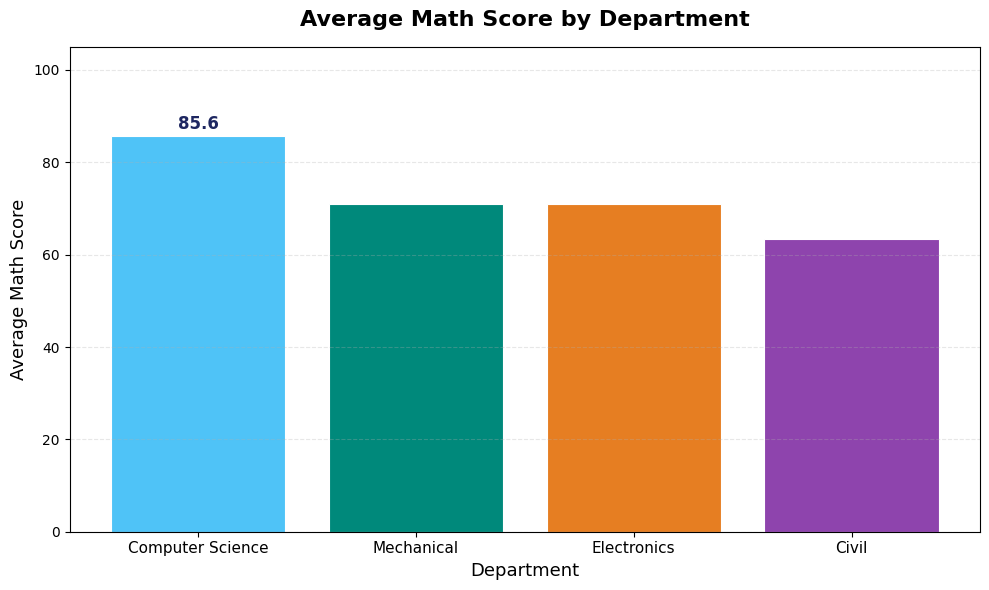

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [130]:
chart1_sql = """
  Select department, round(avg(math_score),2) as avg_math
  from students
  group by department
  order by avg_math desc
"""
chart1_data = pd.read_sql_query(chart1_sql, conn)

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ['#4FC3F7', '#00897B' , '#E67E22' , '#8E44AD']

bars=ax.bar(
    chart1_data['department'],
    chart1_data['avg_math'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)

for bar in bars:
  height=bar.get_height()
  ax.text(
      bar.get_x()+bar.get_width()/2,
      height+0.8,
      f'{height:.1f}',
      ha='center',
      va='bottom',
      fontsize=12,
      fontweight='bold',
      color='#1E2761'
  )

  ax.set_title('Average Math Score by Department', fontsize=16, fontweight='bold',pad=15)
  ax.set_xlabel('Department', fontsize=13)
  ax.set_ylabel('Average Math Score', fontsize=13)
  ax.set_ylim(0,105)
  ax.tick_params(axis='x', labelsize=11)
  ax.grid(axis='y',alpha=0.3, linestyle='--')

  plt.tight_layout()
  plt.show()

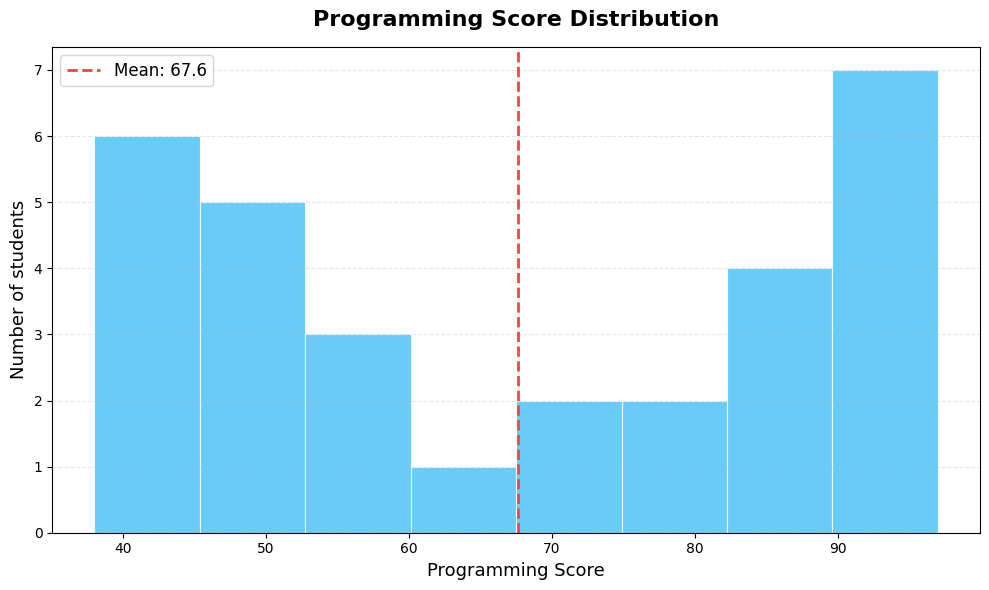

In [131]:
prog_scores=df['programming_score'].tolist()

fig,ax = plt.subplots(figsize=(10,6))

n,bins,patches=ax.hist(
    prog_scores,
    bins=8,
    color='#4FC3F7',
    edgecolor='white',
    linewidth=0.8,
    alpha=0.85
)

mean_score=sum(prog_scores)/len(prog_scores)
ax.axvline(
    x=mean_score,
    color='#E74C3C',
    linestyle='--',
    linewidth=2,
    label=f'Mean: {mean_score:.1f}'
)

ax.set_title('Programming Score Distribution', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Programming Score', fontsize=13)
ax.set_ylabel('Number of students', fontsize=13)
ax.legend(fontsize=12)
ax.grid(axis='y',alpha=0.3,linestyle='--')
plt.tight_layout()
plt.show()

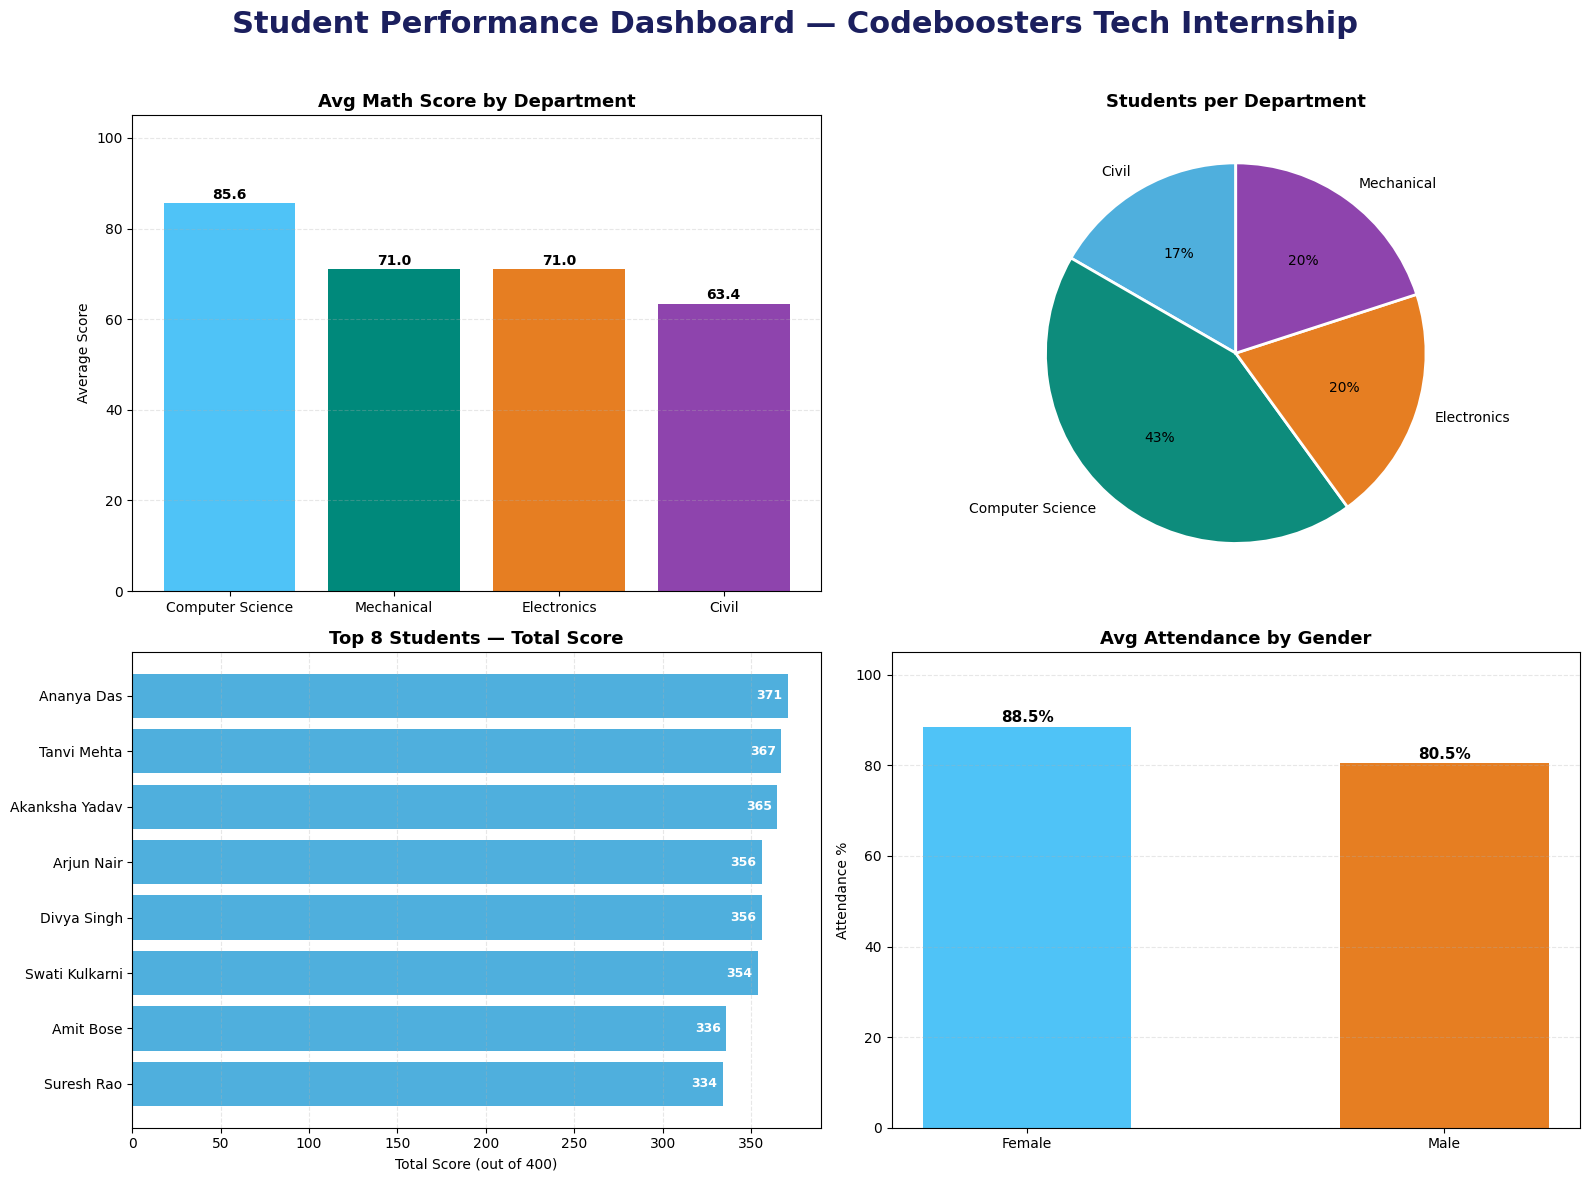

In [132]:
# QUERY 1: AVG MATH SCORE BY DEPARTMENT


chart1_sql = """
SELECT department,
       ROUND(AVG(math_score), 1) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)


# QUERY 2: STUDENT COUNT PER DEPARTMENT


chart2_sql = """
SELECT department,
       COUNT(*) AS total_students
FROM students
GROUP BY department
"""

chart2_data = pd.read_sql_query(chart2_sql, conn)


# QUERY 3: TOP 8 STUDENTS BY TOTAL SCORE


chart3_sql = """
SELECT name,
       (math_score + science_score + english_score + programming_score) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
"""

chart3_data = pd.read_sql_query(chart3_sql, conn)


# QUERY 4: AVG ATTENDANCE BY GENDER


chart4_sql = """
SELECT gender,
       ROUND(AVG(attendance_percentage), 1) AS avg_attendance
FROM students
GROUP BY gender
"""

chart4_data = pd.read_sql_query(chart4_sql, conn)


# CREATE DASHBOARD


fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# PANEL 1 : AVG MATH SCORE BY DEPARTMENT


ax1 = axes[0, 0]

colors1 = ['#4FC3F7', '#00897B', '#E67E22', '#8E44AD']

bars1 = ax1.bar(
    chart1_data['department'],
    chart1_data['avg_math'],
    color=colors1
)

ax1.set_title("Avg Math Score by Department",
              fontsize=13,
              fontweight='bold')

ax1.set_ylabel("Average Score")
ax1.set_ylim(0, 105)


ax1.grid(axis='y', linestyle='--', alpha=0.3)


for bar in bars1:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )


# PANEL 2 : PIE CHART


ax2 = axes[0, 1]

pie_colors = ['#4FAFDD', '#0D8C7C', '#E67E22', '#8E44AD']

ax2.pie(
    chart2_data['total_students'],
    labels=chart2_data['department'],
    autopct='%1.0f%%',
    startangle=90,
    colors=pie_colors,
    wedgeprops={
        'edgecolor': 'white',
        'linewidth': 2
    }
)

ax2.set_title("Students per Department",
              fontsize=13,
              fontweight='bold')


# PANEL 3 : TOP 8 STUDENTS


ax3 = axes[1, 0]

# Reverse order so topper appears at top
chart3_data = chart3_data[::-1]

bars3 = ax3.barh(
    chart3_data['name'],
    chart3_data['total_score'],
    color='#4FAFDD'
)

ax3.set_title("Top 8 Students — Total Score",
              fontsize=13,
              fontweight='bold')

ax3.set_xlabel("Total Score (out of 400)")

# Grid lines
ax3.grid(axis='x', linestyle='--', alpha=0.3)

# Score Labels Inside Bars
for bar in bars3:
    width = bar.get_width()
    ax3.text(
        width - 3,
        bar.get_y() + bar.get_height()/2,
        f'{int(width)}',
        va='center',
        ha='right',
        color='white',
        fontsize=9,
        fontweight='bold'
    )


# PANEL 4 : ATTENDANCE BY GENDER


ax4 = axes[1, 1]

colors4 = ['#4FC3F7', '#E67E22']

bars4 = ax4.bar(
    chart4_data['gender'],
    chart4_data['avg_attendance'],
    color=colors4,
    width=0.5
)

ax4.set_title("Avg Attendance by Gender",
              fontsize=13,
              fontweight='bold')

ax4.set_ylabel("Attendance %")
ax4.set_ylim(0, 105)

# Grid lines
ax4.grid(axis='y', linestyle='--', alpha=0.3)

# Percentage Labels
for bar in bars4:
    height = bar.get_height()
    ax4.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )


# MAIN DASHBOARD TITLE


fig.suptitle(
    "Student Performance Dashboard — Codeboosters Tech Internship",
    fontsize=22,
    fontweight='bold',
    color='#1B1F5E'
)


plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

Practice Questions


Question 1: Write a SQL query to find the average programming score for female students only.

Question 2: What is the difference between WHERE and HAVING? Write one example of each using the students table.

Question 3: Write a SQL query to find all departments where the average attendance is above 85%.

Question 4: What does pd.read_sql_query() return? What two arguments does it require?

Question 5: Modify Chart 1 (bar chart) to show average PROGRAMMING scores instead of math scores.

In [133]:
query1 = """
SELECT ROUND(AVG(programming_score), 1) AS avg_programming_score
FROM students
WHERE gender = 'Female'
"""

result1 = pd.read_sql_query(query1, conn)

print(result1)

   avg_programming_score
0                   70.2


In [134]:
query_where = """
SELECT name, math_score
FROM students
WHERE math_score > 80
"""

result_where = pd.read_sql_query(query_where, conn)

print(result_where)

              name  math_score
0     Aarav Sharma          85
1       Arjun Nair          92
2      Divya Singh          88
3       Ananya Das          95
4       Suresh Rao          83
5     Ritu Agarwal          87
6   Swati Kulkarni          90
7      Tanvi Mehta          93
8        Amit Bose          86
9    Gaurav Shukla          84
10  Akanksha Yadav          91


In [135]:
query3 = """
SELECT department,
       ROUND(AVG(attendance_percentage), 1) AS avg_attendance
FROM students
GROUP BY department
HAVING AVG(attendance_percentage) > 85
"""

result3 = pd.read_sql_query(query3, conn)

print(result3)

         department  avg_attendance
0  Computer Science            90.7


In [136]:
data = pd.read_sql_query(
    "SELECT * FROM students",
    conn
)

print(data)

    student_id            name  age  gender        department  semester  \
0         1001    Aarav Sharma   19    Male  Computer Science         2   
1         1002     Priya Patel   20  Female  Computer Science         2   
2         1003     Rohit Verma   19    Male       Electronics         2   
3         1004     Sneha Reddy   20  Female        Mechanical         2   
4         1005      Arjun Nair   19    Male  Computer Science         2   
5         1006     Meera Joshi   20  Female       Electronics         2   
6         1007     Kiran Kumar   21    Male             Civil         2   
7         1008     Divya Singh   19  Female  Computer Science         2   
8         1009    Rahul Mishra   20    Male        Mechanical         2   
9         1010      Ananya Das   19  Female  Computer Science         2   
10        1011     Vikram Iyer   20    Male       Electronics         2   
11        1012     Pooja Gupta   19  Female             Civil         2   
12        1013      Sures

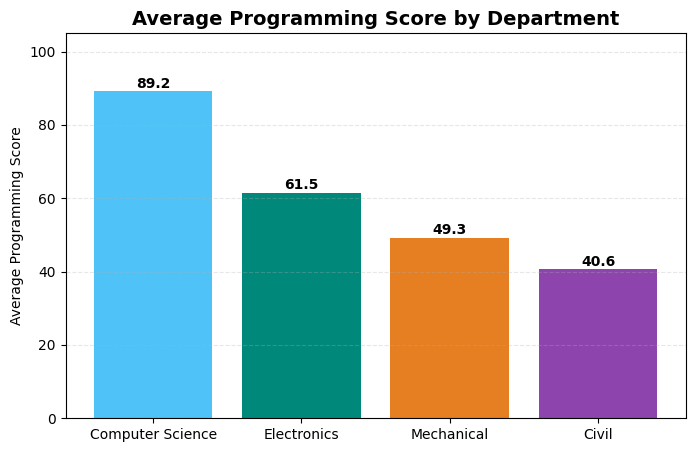

In [137]:
# =========================================
# AVG PROGRAMMING SCORE BY DEPARTMENT
# =========================================

chart1_sql = """
SELECT department,
       ROUND(AVG(programming_score), 1) AS avg_programming
FROM students
GROUP BY department
ORDER BY avg_programming DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)

# --------------------------------
# BAR CHART
# --------------------------------

plt.figure(figsize=(8, 5))

colors = ['#4FC3F7', '#00897B', '#E67E22', '#8E44AD']

bars = plt.bar(
    chart1_data['department'],
    chart1_data['avg_programming'],
    color=colors
)

plt.title(
    "Average Programming Score by Department",
    fontsize=14,
    fontweight='bold'
)

plt.ylabel("Average Programming Score")

plt.ylim(0, 105)

# Grid lines
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Value labels
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.show()